In [76]:
import pandas as pd
import numpy as np
import zipfile
from matplotlib import pyplot as py
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### 1 - Dataset loading from local

In [79]:
#Personal lap path
zip_path = r"D:\Veena\Certificate Program in AI and ML\Dataset.zip"
#office lap path
#zip_path = r"E:\Veena\Certificate-Program-in-AIML-IIT-Patna\MODULE 2 - CLASSICAL ML\Dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    ibmTelecoChurnDF = pd.read_csv(z.open("Dataset/telco_customer_churn.csv"))


In [9]:
ibmTelecoChurnDF.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2 - Checking if any null values are present in the dataset

In [10]:
ibmTelecoChurnDF.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
ibmTelecoChurnDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3 - Checking the distribution of values in the target column

In [14]:
ibmTelecoChurnDF['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
ibmTelecoChurnDF['Churn'].value_counts()

### 4 - Plotting the target column

<Axes: xlabel='Churn', ylabel='count'>

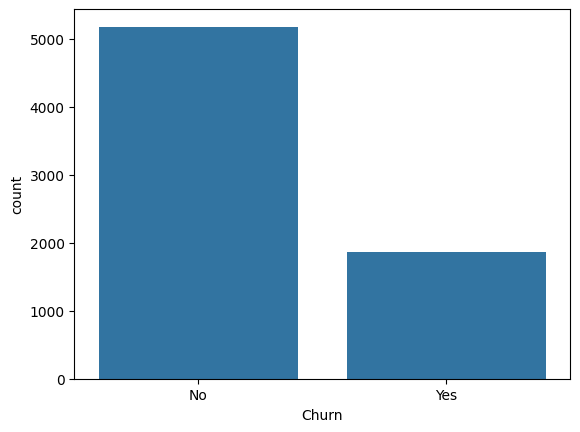

In [20]:
churnCount = ibmTelecoChurnDF['Churn'].value_counts()
sns.barplot(churnCount)

([<matplotlib.patches.Wedge at 0x1f6f531c7d0>,
 [Text(-0.7393678155529122, 0.8144539479458092, 'No'),
  Text(0.7393680809356542, -0.8144537070291521, 'Yes')])

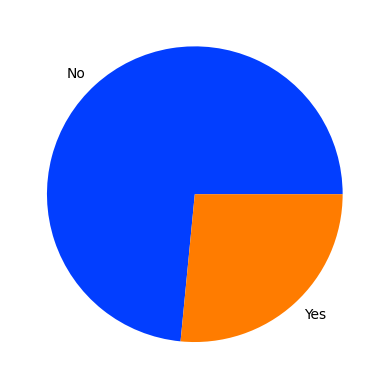

In [23]:
colours = sns.color_palette('bright')
py.pie(churnCount.values, labels=churnCount.index,colors=colours)

#### From above, it is clear that the dataset is imbalanced.

- And also, the "Total Charges" column is in string format.

In [28]:
sum(ibmTelecoChurnDF['TotalCharges'] == ' ')

11

In [29]:
ibmTelecoChurnDF['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [37]:
ibmTelecoChurnDF.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

### 5. Converting "Churn" column to binary values

In [42]:
#Converting the obtained boolean value(Yes-> 1, No-> 0) from ibmTelecoChurnDF['Churn'] == 'Yes', to integer type as 1 and 0.
ibmTelecoChurnDF['ChurnInt'] = (ibmTelecoChurnDF['Churn'] == 'Yes').astype(int)
ibmTelecoChurnDF['ChurnInt'].value_counts()

ChurnInt
0    5174
1    1869
Name: count, dtype: int64

In [51]:
ibmTelecoChurnDF.groupby('Contract')['ChurnInt'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: ChurnInt, dtype: float64

In [54]:
ibmTelecoChurnDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 6 - Fixing the issues in the dataset

#### 6.1 - Converting "Total Charges" column to float type and replacing the null values with median of the column

In [56]:
#Convert "Total Charges" column into numeric
ibmTelecoChurnDF['TotalCharges'] = pd.to_numeric(ibmTelecoChurnDF['TotalCharges'],errors='coerce')


In [59]:
ibmTelecoChurnDF['TotalCharges']=ibmTelecoChurnDF['TotalCharges'].fillna(0)
ibmTelecoChurnDF['TotalCharges'].info()

<class 'pandas.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


#### 6.2 - Dropping the "customerID" column as it is not required for model building

In [61]:

#Droping the unnecessary column - customer ID
ibmTelecoChurnDF = ibmTelecoChurnDF.drop('customerID',axis=1)

In [62]:
ibmTelecoChurnDF.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'ChurnInt'],
      dtype='str')

#### 6.3 - Seperating the categorical and numerical columns and defining a preprocessor to handle for the categorical and numerical columns

In [63]:
numCols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
catogoryCols = [c for c in ibmTelecoChurnDF.columns if c not in numCols + ['Churn']]

print(f"Numeric columns: {numCols}")
print(f"Category columns: {catogoryCols}")

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Category columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'ChurnInt']


In [ ]:
## Building a Prepocessor
## Usually, we use to apply standard scalar on numeric columns and on-hot encoding omn categorical columns. This is a away of doing manually. But this can be automated.
#The below is just definition of the automated column transformer.
preprocessor = ColumnTransformer(
    [
        ('num',StandardScaler(),numCols),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),catogoryCols)
    ]
)

### 7 - Splitting the dataset into train and test sets

In [72]:
x = ibmTelecoChurnDF.drop(['Churn','ChurnInt'],axis=1)
y = ibmTelecoChurnDF['ChurnInt']

xTrain,xTest,yTrain,yTest = train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)

print(f"Train samples : {len(xTrain)} samples | Churn Rate: {yTrain.mean():.2%}")
print(f"Test samples : {len(xTest)} samples | Churn Rate: {yTest.mean():.2%}")

Train samples : 5282 samples | Churn Rate: 26.54%
Test samples : 1761 samples | Churn Rate: 26.52%


In [73]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [78]:
model = {
    'Logistic Regression' : LogisticRegression(max_iter=1000,class_weight='balaced',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(max_depth=5,class_weight='balanced',random_state=42),
    #Below,n_jobs means how many cpu cores to use to run computation in paralle. -1 indicates use all cores available in my lap.
    'Random Forest' : RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)

}